In [36]:
!pip install geemap earthengine-api folium

# นำเข้าไลบรารี
import ee
import geemap
import folium

# เชื่อมต่อ Google Earth Engine
try:
    ee.Initialize(project='lluktarn')  # ใช้โปรเจกต์ GEE ที่ตั้งค่าไว้
    print("GEE Initialized Successfully!")
except Exception as e:
    print("ต้องทำการยืนยันตัวตน GEE")
    ee.Authenticate()
    ee.Initialize(project='lluktarn')

GEE Initialized Successfully!


In [37]:
# โหลดขอบเขตจังหวัดเชียงใหม่จาก GEE Asset (หากมี)
asset_path = 'projects/borsorxj/assets/chiangmai_boundary'

try:
    chiangmai_boundary = ee.FeatureCollection(asset_path)
    print("โหลดขอบเขตจังหวัดเชียงใหม่สำเร็จ!")
except Exception as e:
    print("ไม่พบข้อมูลขอบเขตจังหวัดเชียงใหม่:", e)


โหลดขอบเขตจังหวัดเชียงใหม่สำเร็จ!


In [38]:
# โหลดข้อมูลขอบเขตจังหวัดเชียงใหม่จาก GEE Assets
chiangmai_image = ee.Image("projects/lluktarn/assets/ChiangMai_Boundary")

# ดึงขอบเขตเป็น Geometry และสร้าง FeatureCollection
chiangmai_boundary = chiangmai_image.geometry()
chiangmai_boundary_fc = ee.FeatureCollection([ee.Feature(chiangmai_boundary)])

# กำหนดให้ Mask พื้นที่นอกขอบเขต (ทำให้โปร่งใส)
chiangmai_masked = chiangmai_image.updateMask(chiangmai_image)

# สร้างแผนที่
Map = geemap.Map()
Map.centerObject(chiangmai_boundary, 8)  # โฟกัสไปที่ขอบเขตจังหวัด

# เพิ่ม Layer ขอบเขต
Map.addLayer(chiangmai_masked, {"palette": ["red"], "opacity": 0.8}, "Chiang Mai Region")  # แสดงพื้นที่ในจังหวัด


# แสดงแผนที่
Map


Map(center=[18.709477672279288, 98.79222336412307], controls=(WidgetControl(options=['position', 'transparent_…

In [28]:
import ee
import geemap

# โหลดขอบเขตจังหวัดเชียงใหม่จาก GEE Assets
chiangmai_image = ee.Image("projects/lluktarn/assets/ChiangMai_Boundary")
chiangmai_boundary = chiangmai_image.geometry()

# ฟังก์ชันคำนวณ NDVI
def compute_ndvi(image):
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")  # (NIR - Red) / (NIR + Red)
    return image.addBands(ndvi)

# กำหนดวันที่ที่ต้องการเปรียบเทียบ
start_date_1 = "2023-01-01"
end_date_1 = "2023-03-31"

start_date_2 = "2022-01-01"
end_date_2 = "2022-03-31"

# โหลดภาพ Sentinel-2 และตัดเฉพาะจังหวัดเชียงใหม่
sentinel_1 = ee.ImageCollection("COPERNICUS/S2_SR") \
    .filterBounds(chiangmai_boundary) \
    .filterDate(start_date_1, end_date_1) \
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20)) \
    .median() \
    .clip(chiangmai_boundary)

sentinel_2 = ee.ImageCollection("COPERNICUS/S2_SR") \
    .filterBounds(chiangmai_boundary) \
    .filterDate(start_date_2, end_date_2) \
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20)) \
    .median() \
    .clip(chiangmai_boundary)

# คำนวณ NDVI
ndvi_1 = compute_ndvi(sentinel_1).select("NDVI").clip(chiangmai_boundary)
ndvi_2 = compute_ndvi(sentinel_2).select("NDVI").clip(chiangmai_boundary)

# ใช้ Mask เพื่อลบค่าภายนอกเชียงใหม่ออก
ndvi_1 = ndvi_1.updateMask(chiangmai_image)
ndvi_2 = ndvi_2.updateMask(chiangmai_image)

# สร้างแผนที่
Map = geemap.Map()
Map.centerObject(chiangmai_boundary, 8)

# แสดงผล NDVI เฉพาะจังหวัดเชียงใหม่
Map.addLayer(ndvi_1, {"min": 0, "max": 1, "palette": ["red", "yellow", "green"]}, "NDVI 2023")
Map.addLayer(ndvi_2, {"min": 0, "max": 1, "palette": ["red", "yellow", "green"]}, "NDVI 2022")

# ไม่แสดงเส้นขอบเขตจังหวัดเชียงใหม่
# Map.addLayer(ee.FeatureCollection([ee.Feature(chiangmai_boundary)]), {"color": "black"}, "Chiang Mai Boundary")  # ลบออก

# แสดงแผนที่
Map


Map(center=[18.709477672279288, 98.79222336412307], controls=(WidgetControl(options=['position', 'transparent_…

In [29]:
# คำนวณการเปลี่ยนแปลง NDVI
ndvi_diff = ndvi_2.subtract(ndvi_1).rename("NDVI Change")

# แสดงแผนที่
Map = geemap.Map()
Map.centerObject(chiangmai_boundary, 8)
Map.addLayer(ndvi_diff, {"min": -0.3, "max": 0.3, "palette": ["red", "white", "green"]}, "NDVI Change")
Map


Map(center=[18.709477672279288, 98.79222336412307], controls=(WidgetControl(options=['position', 'transparent_…

In [32]:
# โหลดขอบเขตจังหวัดเชียงใหม่จาก GEE Assets
chiangmai_image = ee.Image("projects/lluktarn/assets/ChiangMai_Boundary")
chiangmai_boundary = chiangmai_image.geometry()

# โหลดข้อมูล DEM (SRTM) และใช้ updateMask เพื่อให้แสดงเฉพาะในขอบเขตจังหวัดเชียงใหม่
dem = ee.Image("USGS/SRTMGL1_003").updateMask(chiangmai_image)  # ใช้ updateMask เพื่อลบข้อมูลนอกเชียงใหม่

# สร้างแผนที่
Map = geemap.Map()
Map.centerObject(chiangmai_boundary, 8)

# แสดงแผนที่ DEM เฉพาะพื้นที่ในจังหวัดเชียงใหม่
Map.addLayer(dem, {"min": 0, "max": 3000, "palette": ["blue", "green", "yellow", "brown"]}, "DEM")

# แสดงแผนที่
Map




Map(center=[18.709477672279288, 98.79222336412307], controls=(WidgetControl(options=['position', 'transparent_…

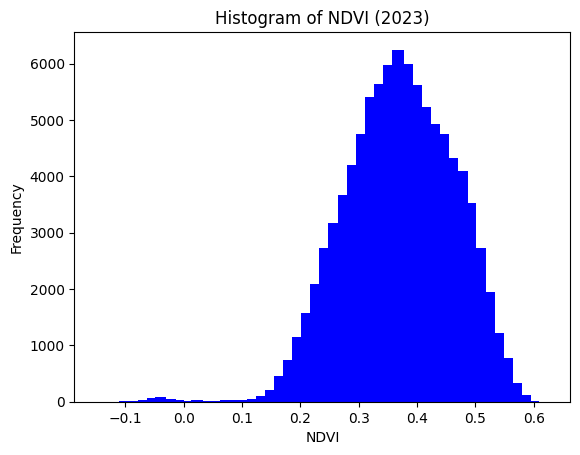

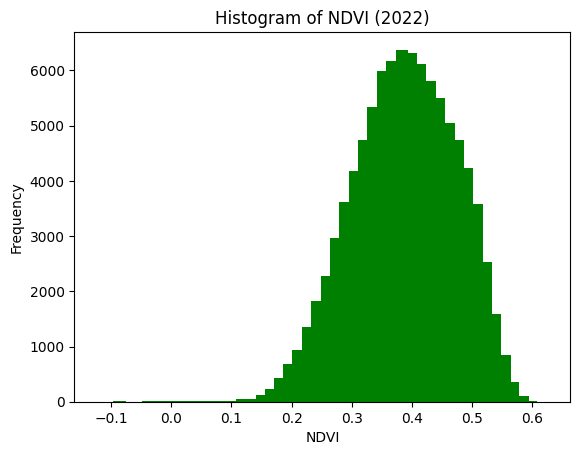

In [33]:
import matplotlib.pyplot as plt

# ฟังก์ชันช่วยสร้าง Histogram
def plot_histogram(image, title, color):
    histogram = image.reduceRegion(
        reducer=ee.Reducer.histogram(50),
        geometry=chiangmai_boundary,
        scale=500,
        bestEffort=True
    ).get("NDVI").getInfo()

    plt.bar(histogram["bucketMeans"], histogram["histogram"], width=0.02, color=color)
    plt.xlabel("NDVI")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

# Histogram ของ NDVI ปี 2023
plot_histogram(ndvi_1, "Histogram of NDVI (2023)", "blue")

# Histogram ของ NDVI ปี 2022
plot_histogram(ndvi_2, "Histogram of NDVI (2022)", "green")


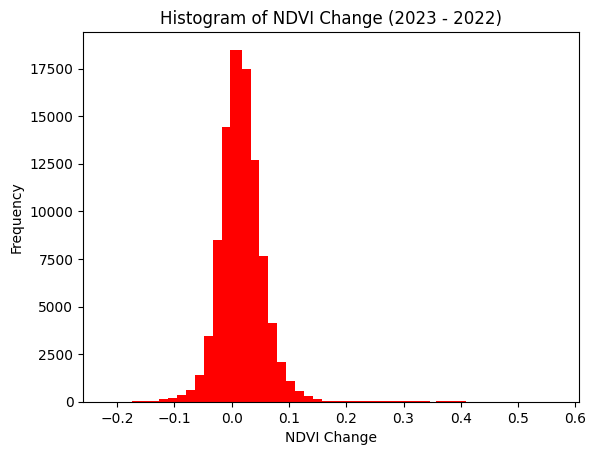

In [34]:
# ดึงค่าพิกเซล NDVI Change
ndvi_histogram = ndvi_diff.reduceRegion(
    reducer=ee.Reducer.histogram(50),
    geometry=chiangmai_boundary,
    scale=500,
    bestEffort=True
).get("NDVI Change").getInfo()

# แสดง Histogram ของ NDVI Change
plt.bar(ndvi_histogram["bucketMeans"], ndvi_histogram["histogram"], width=0.02, color="red")
plt.xlabel("NDVI Change")
plt.ylabel("Frequency")
plt.title("Histogram of NDVI Change (2023 - 2022)")
plt.show()

      type    id  geometry.geodesic geometry.type  \
0  Feature   0_0              False         Point   
1  Feature   3_0              False         Point   
2  Feature   4_0              False         Point   
3  Feature   8_0              False         Point   
4  Feature  12_0              False         Point   

                      geometry.coordinates  properties.NDVI  \
0     [99.08193005017293, 19.338482278883]         0.432679   
1    [98.7585365478899, 18.92525724818802]         0.346169   
2   [98.1791231896328, 18.525506946754835]         0.553865   
3  [98.64624713737496, 18.273978667201366]         0.303234   
4   [98.5743819146454, 18.916274095346825]         0.352724   

   properties.elevation  
0                   991  
1                   599  
2                  1295  
3                   271  
4                   729  


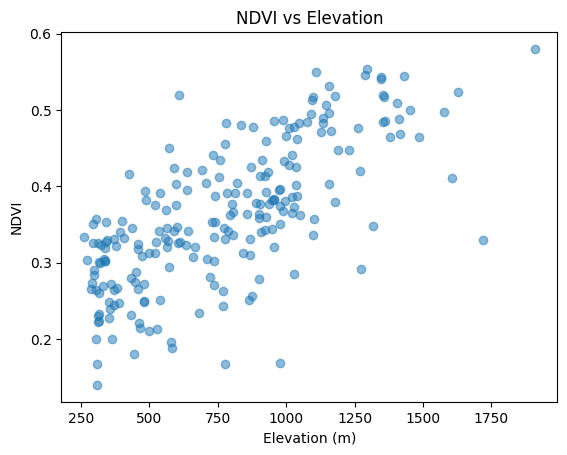

In [35]:
import ee
import pandas as pd
import matplotlib.pyplot as plt

# โหลดข้อมูลความสูง SRTM DEM
dem = ee.Image("USGS/SRTMGL1_003")

# ผสาน NDVI และ DEM เข้าด้วยกัน
ndvi_elevation = ndvi_1.addBands(dem)

# สุ่มจุดตัวอย่างจากพื้นที่ศึกษา
random_points = ee.FeatureCollection.randomPoints(region=chiangmai_boundary, points=500, seed=42)

# ดึงค่าคุณลักษณะ NDVI และ Elevation จากจุดตัวอย่าง
samples = ndvi_elevation.sampleRegions(
    collection=random_points,
    scale=500,
    projection="EPSG:4326",
    geometries=True
)

# แปลงเป็น DataFrame สำหรับ Matplotlib
features = samples.getInfo()["features"]  # ดึงค่าจาก GEE
df = pd.json_normalize(features)  # แปลงเป็น DataFrame

#ตรวจสอบว่าข้อมูลถูกต้องหรือไม่
print(df.head())

# ปรับการดึงค่าตามโครงสร้างข้อมูลจริง
elevation_values = df["properties.elevation"]
ndvi_values = df["properties.NDVI"]

# แสดงผลด้วย Matplotlib
plt.scatter(elevation_values, ndvi_values, alpha=0.5)
plt.xlabel("Elevation (m)")
plt.ylabel("NDVI")
plt.title("NDVI vs Elevation")
plt.show()


1.
- ติดตามการเปลี่ยนแปลงของพืชพรรณ เช่น การเติบโตหรือการเสื่อมโทรม

- ระบุแนวโน้มด้านสิ่งแวดล้อม เช่น ภัยแล้ง การบุกรุกป่า หรือการเปลี่ยนแปลงการใช้ที่ดิน

---


2.
-เปรียบเทียบกับข้อมูลภาคสนามหรือภาพถ่ายความละเอียดสูง

-วิเคราะห์ปัจจัยแวดล้อม เช่น สภาพอากาศ การใช้ที่ดิน และกิจกรรมมนุษย์

-ใช้ข้อมูลจากเซ็นเซอร์อื่น เช่น ความชื้นดิน อุณหภูมิพื้นผิว


---


 3.
-เมฆ ฝุ่น หมอก หรือเงา ทำให้การสะท้อนแสงผิดเพี้ยน

-มุมถ่ายภาพของดาวเทียมที่แตกต่างกัน

-การเปลี่ยนแปลงของความชื้นในดินหรือโครงสร้างของดิน


---


4.
-ใช้ภาพจากหลายแหล่งและหลายช่วงคลื่น เช่น SAR (เรดาร์)

-ใช้การปรับแก้เชิงรังสีเพื่อลดผลกระทบจากชั้นบรรยากาศ

-วิเคราะห์ร่วมกับ AI หรือ Machine Learning เพื่อจำแนกลักษณะการเปลี่ยนแปลง


---


5.
-แสดงผลกระทบจากภูมิประเทศ เช่น ความสูงและความลาดเอียง

-ช่วยแยกแยะการเปลี่ยนแปลง NDVI ที่เกิดจากเงาภูเขาหรือการไหลของน้ำ

-สนับสนุนการวิเคราะห์ระบบนิเวศ เช่น ความสัมพันธ์ระหว่างความชื้นและพืชพรรณ

